## PACOTES 

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import entropy
import time

 ## ESTUDO INICIAL SOBRE TARGET

### CONTAGEM E PROPORCAO

status_fraude
0    284315
1       492
Name: count, dtype: int64
status_fraude
0    99.827251
1     0.172749
Name: proportion, dtype: float64


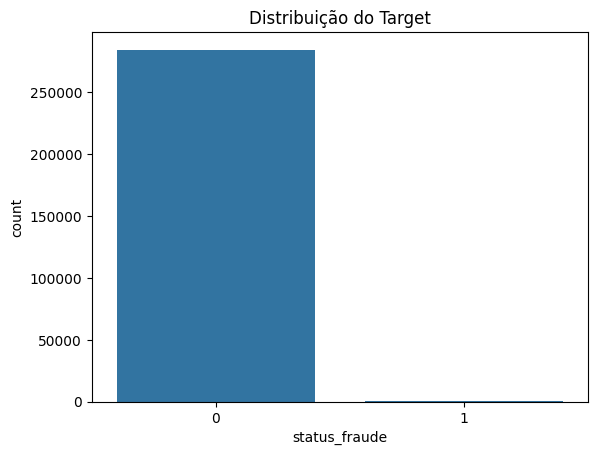

In [12]:
df = pd.read_csv('creditcard.csv')

contagem = df['status_fraude'].value_counts()
percentual = df['status_fraude'].value_counts(normalize=True) * 100

print(contagem)
print(percentual)

sns.countplot(data=df, x='status_fraude')

plt.title('Distribuição do Target')
plt.show()


### AVALIACAO DE DESBALANCEAMENTO

In [13]:
# 1. Calcular as probabilidades (proporções)
counts = df['status_fraude'].value_counts(normalize=True)
probabilidades = counts.values

# 2. Calcular a entropia de Shannon
# O parâmetro base=2 define a medida em bits
ent_target = entropy(probabilidades, base=2)

print(f"Entropia da Target (status_fraude): {ent_target:.4f} bits")

# Interpretação rápida
if ent_target < 0.1:
    print("Incerteza muito baixa: Classe altamente desbalanceada.")
elif ent_target > 0.9:
    print("Incerteza alta: Classes bem equilibradas.")

Entropia da Target (status_fraude): 0.0183 bits
Incerteza muito baixa: Classe altamente desbalanceada.


### ANÁLISE DA RARIDADE DO EVENTO

In [14]:
fraude_rate = df['status_fraude'].mean()

raridade = 1 / fraude_rate

print(f'1 fraude a cada {raridade:.0f} transações')

1 fraude a cada 579 transações


### FRAUDES ACUMULADAS

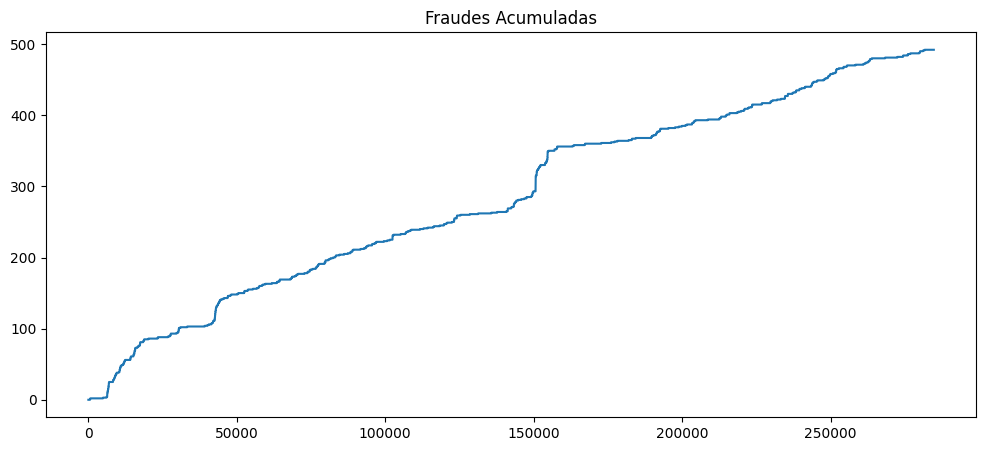

In [15]:
df['status_fraude'].cumsum().plot(figsize=(12,5))

plt.title('Fraudes Acumuladas')
plt.show()
